In [1]:
# this notebook will normalize(scale)/ clean the data
# while keeping key level as feature
import pandas as pd
import json
from pathlib import Path

def find_project_root(marker=".git"):
    p = Path.cwd()
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError("Project root not found")

folder_path = find_project_root() / "data" / "mlData"

# src_path = folder_path / "raw" / "BTCUSD-5m-v5-B.jsonl"
src_path = folder_path / "augmented" / "BTCUSD-5m-v7-augmented.jsonl"

# Read JSONL file - keep timestamp as raw number
df = pd.read_json(src_path, lines=True, convert_dates=False)
df.head()

,timestamp,open,high,low,close,vol,atr42,ts_5m,label,train_mask,close_fracdiff
0,1704037500000,42497.851562,42518.148438,42480.691406,42482.250000,56.512959,NaN,1704037500000,0,0,NaN
1,1704037800000,42482.238281,42500.000000,42411.101562,42414.421875,47.354488,NaN,1704037800000,0,0,NaN
2,1704038100000,42414.429688,42471.988281,42414.421875,42457.171875,43.228668,NaN,1704038100000,0,0,NaN
3,1704038400000,42457.171875,42484.828125,42436.468750,42449.601562,74.418266,NaN,1704038400000,0,0,NaN
4,1704038700000,42449.589844,42488.000000,42449.589844,42487.988281,38.818489,NaN,1704038700000,0,0,NaN


In [2]:
# tactical drop
# atr42 and ts_5m
df.drop(columns=['atr42', 'ts_5m'], inplace=True)

In [3]:
# clean
# removing warmup nan
# check label imbalance
import numpy as np
# clean — drop warmup NaN rows (longest window: vol_norm rolling 96 → 95 rows)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
scale_cols = ['close_fracdiff']
df_clean = df.dropna(subset=scale_cols).reset_index(drop=True)


dropped = len(df) - len(df_clean)
print(f"Rows before : {len(df):,}")
print(f"Rows dropped: {dropped:,}  (warmup NaN from rolling windows)")
print(f"Rows after  : {len(df_clean):,}")

# check label imbalance — only on trainable rows (train_mask=1)
trainable = df_clean[df_clean['train_mask'] == 1]
n_up   = (trainable['label'] ==  1).sum()
n_down = (trainable['label'] == -1).sum()
total  = len(trainable)

print(f"\nLabel balance (trainable only):")
print(f"  Up   ( 1) : {n_up:,}  ({n_up   / total * 100:.1f}%)")
print(f"  Down (-1) : {n_down:,}  ({n_down / total * 100:.1f}%)")
print(f"  Total     : {total:,}  ({total / len(df_clean) * 100:.1f}% of clean rows)")
print(f"  Timeout   : {(df_clean['train_mask'] == 0).sum():,}")


Rows before : 228,772
Rows dropped: 199  (warmup NaN from rolling windows)
Rows after  : 228,573

Label balance (trainable only):
  Up   ( 1) : 76,171  (49.5%)
  Down (-1) : 77,752  (50.5%)
  Total     : 153,923  (67.3% of clean rows)
  Timeout   : 74,650


In [4]:
# Nan and Infinity assert check
assert df_clean.isnull().sum().sum() == 0, "NaN leaked through!"
assert not np.isinf(df_clean.select_dtypes(include='number').values).any(), "Inf leaked through!"

# Memory test




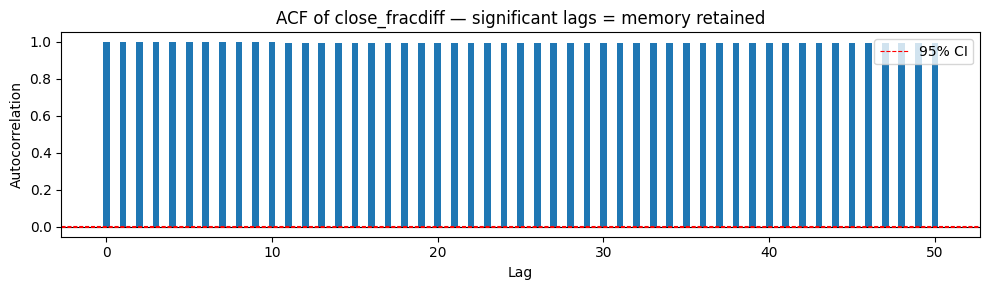


✓ 50/50 lags exceed 95% CI → memory retained


In [5]:
# last verification : features must be stationary and has memory
# Verify close_fracdiff is stationary (ADF) and retains memory (ACF)
from statsmodels.tsa.stattools import adfuller, acf
import matplotlib.pyplot as plt

series = df['close_fracdiff'].dropna()

# --- ACF plot — memory check ---
nlags = 50
acf_vals = acf(series, nlags=nlags)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(acf_vals)), acf_vals, width=0.4)
ax.axhline(0, color='black', linewidth=0.8)
conf = 1.96 / len(series)**0.5
ax.axhline( conf, color='red', linestyle='--', linewidth=0.8, label='95% CI')
ax.axhline(-conf, color='red', linestyle='--', linewidth=0.8)
ax.set_title("ACF of close_fracdiff — significant lags = memory retained")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend()
plt.tight_layout()
plt.show()

sig_lags = (abs(acf_vals[1:]) > conf).sum()
print(f"\n✓ {sig_lags}/{nlags} lags exceed 95% CI → memory retained" if sig_lags > 0
      else f"\n✗ No significant lags — no memory detected")

In [6]:
print(df_clean.shape)
df_clean.columns

(228573, 9)


Index(['timestamp', 'open', 'high', 'low', 'close', 'vol', 'label',
       'train_mask', 'close_fracdiff'],
      dtype='object')

# Export cleaned data

In [7]:
# save the current data in ./data/mlData/clean-v3
# save to JSONL for training
out_path = folder_path / "clean" / "BTCUSD-5m-v7-input.jsonl"
df_clean.to_json(out_path, orient="records", lines=True)
print(f"final shape : {df_clean.shape}")
print(f"Saved {len(df_clean)} rows to {out_path}")


final shape : (228573, 9)
Saved 228573 rows to /Users/aimliu/Library/CloudStorage/OneDrive-Personal/_CODE/Python/py-CandleScience/data/mlData/clean/BTCUSD-5m-v7-input.jsonl
